In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.transform import Rotation as R

In [44]:
df = pd.read_csv('cleanedDataset.csv')
df.head()
df1 = pd.read_csv('Titanic.csv')

In [45]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

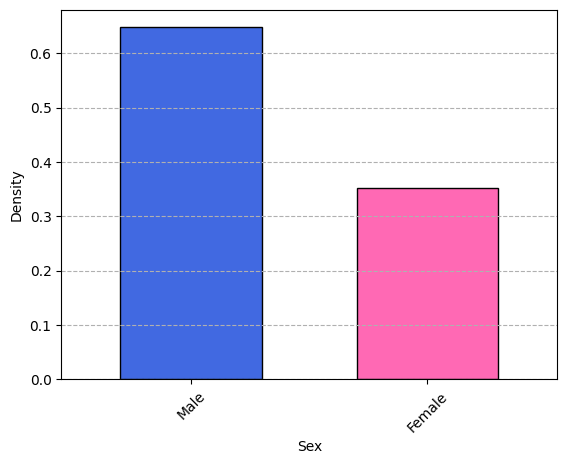

In [46]:
gender = (df['Sex'].value_counts()/df['Sex'].value_counts().sum()).sort_index()

gender.plot(kind='bar', color=['royalblue', 'hotpink'], edgecolor='black', width=0.6)
plt.xticks([0, 1], ['Male', 'Female'], rotation=45)
plt.grid(axis='y', linestyle='--')
plt.ylabel('Density')
plt.show()

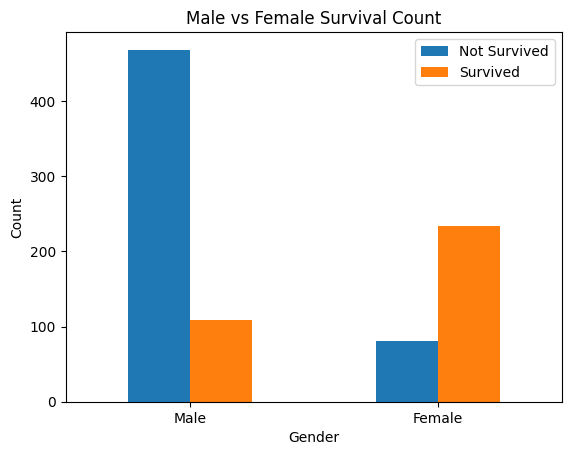

In [47]:
sex_survived = df.groupby(['Sex', 'Survived']).size().unstack()

sex_survived.plot(kind='bar')

plt.title('Male vs Female Survival Count')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.xticks([0, 1], ['Male', 'Female'],rotation=0)
plt.legend(['Not Survived', 'Survived'])

plt.show()

In [48]:
sex_survived

Survived,0,1
Sex,,
0,468,109
1,81,233


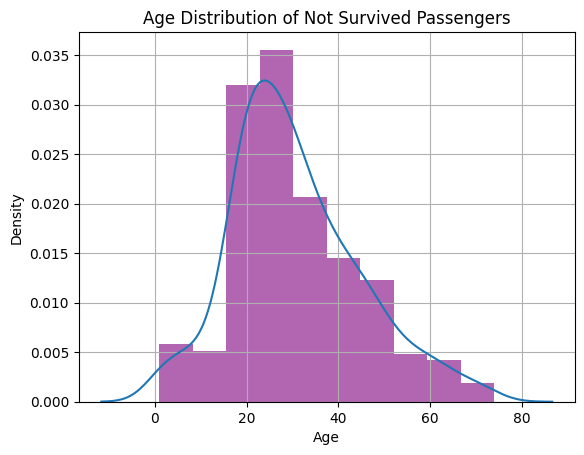

In [49]:
not_survived_age = df1[df1['Survived'] == 0]['Age']

not_survived_age.hist(bins=10, color='purple', density=True, alpha=0.6)

sns.kdeplot(not_survived_age)

plt.title('Age Distribution of Not Survived Passengers')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

In [50]:
not_survived_age.skew()

np.float64(0.5855837826738851)

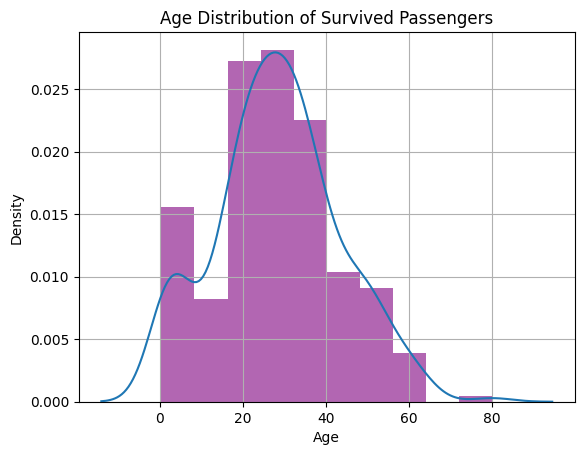

In [51]:
survived_age = df1[df1['Survived'] == 1]['Age']

survived_age.hist(bins=10, color='purple', density=True, alpha=0.6)

sns.kdeplot(survived_age)

plt.title('Age Distribution of Survived Passengers')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

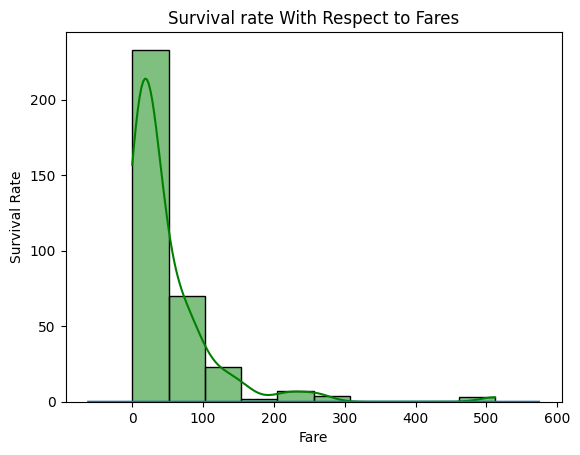

In [52]:
survived_fare = df1[df1['Survived'] == 1]['Fare']

sns.histplot(survived_fare, bins=10, kde=True, color='green')
plt.title('Survival rate With Respect to Fares')
plt.xlabel('Fare')
sns.kdeplot(survived_fare)
plt.ylabel('Survival Rate')
plt.show()

In [53]:
survived_fare.skew()

np.float64(3.8627793799441936)

In [54]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [55]:
cols = ['Sex', 'Age', 'Fare', 'hasCabin']
for col in cols:
    print(f"Correlation of Survived with {col} is {np.corrcoef(df[col], df['Survived'])[0][1]}")

Correlation of Survived with Sex is 0.5433513806577555
Correlation of Survived with Age is -0.06980851528714312
Correlation of Survived with Fare is 0.25730652238496243
Correlation of Survived with hasCabin is 0.3169115231122962


In [56]:
cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S']
corr = 0
for col in cols:
    print(col)
    print(np.corrcoef(df[col], df['Survived'])[0][1])


Embarked_C
0.16824043121823268
Embarked_Q
0.0036503826839719387
Embarked_S
-0.15566027340439306


In [57]:
embarked_table = pd.crosstab(df1['Embarked'], df1['Survived'])
embarked_table.sum()

,0
Survived,
0,549
1,340


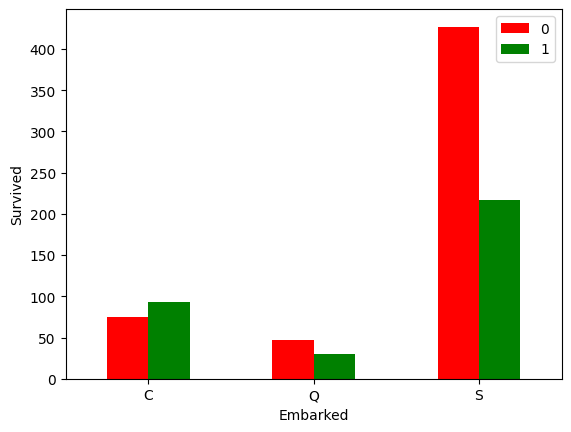

In [58]:
embarked_table.plot(kind='bar', color=['red', 'green'])
plt.xlabel('Embarked')
plt.ylabel('Survived')
plt.legend()
plt.xticks(rotation=0)
plt.show()

In [59]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [60]:
hascabin_df = pd.crosstab(df['hasCabin'], df['Survived'])
hascabin_df

Survived,0,1
hasCabin,,
0,481,206
1,68,136


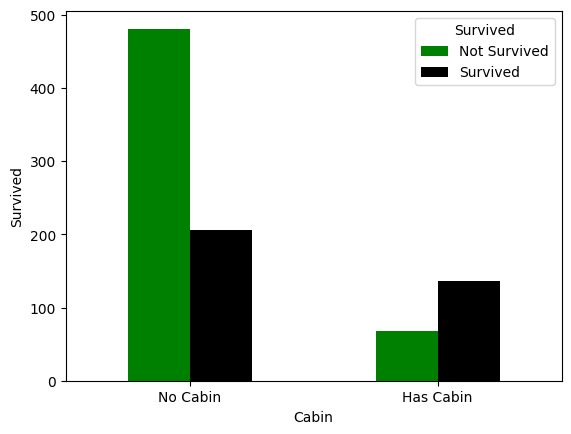

In [61]:
hascabin_df.plot(kind='bar', color=['green', 'black'])
plt.xlabel('Cabin')
plt.ylabel('Survived')
plt.xticks([0, 1], ['No Cabin', 'Has Cabin'], rotation=0)
plt.legend(['Not Survived', 'Survived'], title='Survived')
plt.show()

In [62]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [63]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [64]:
pclass_survived = pd.crosstab(df['Pclass'], df['Survived'])
pclass_survived

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


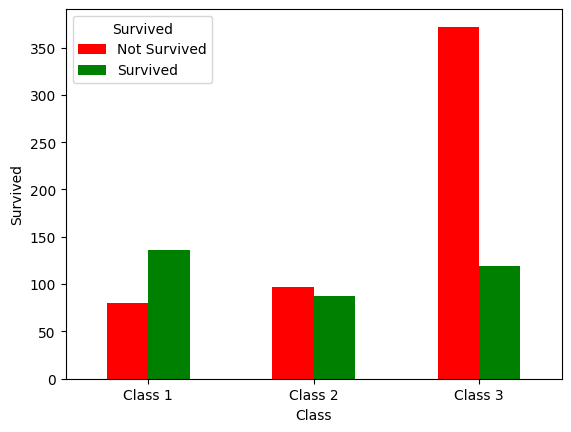

In [65]:
pclass_survived.plot(kind='bar', color=['red', 'green'])
plt.xticks([0, 1, 2], ['Class 1', 'Class 2', 'Class 3'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Survived')
plt.legend(['Not Survived', 'Survived'], title = 'Survived')
plt.show()

In [66]:
class_counts = df['Pclass'].value_counts().sort_values().values
class_categories = df['Pclass'].value_counts().sort_values().index
print(class_counts)
print(class_categories)

[184 216 491]
Index([2, 1, 3], dtype='int64', name='Pclass')


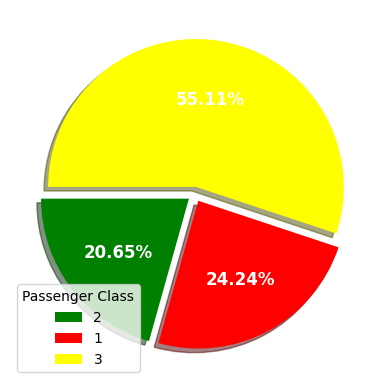

In [67]:
explode = [0.05, 0.05, 0.05]
cat_color = ['green', 'red', 'yellow']
plt.pie(class_counts, labels=class_categories, explode=explode, startangle=180, colors=cat_color, shadow=True
,       autopct='%2.2f%%',  textprops={
        'color': 'white',
        'fontsize': 12,
        'fontweight': 'bold'})
plt.legend(title='Passenger Class')
plt.show()

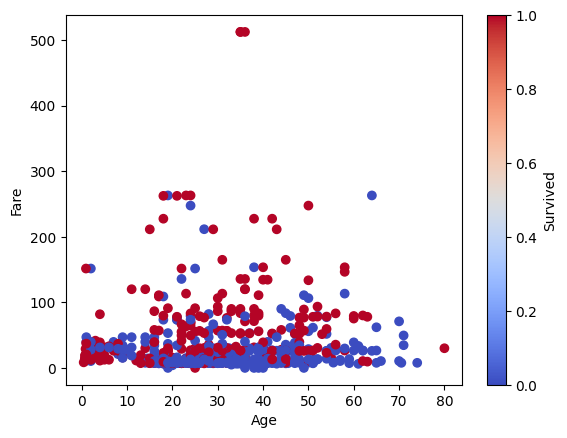

In [68]:
plt.scatter(df1['Age'], df1['Fare'], c = df['Survived'], cmap='coolwarm')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.colorbar(label='Survived')
plt.show()

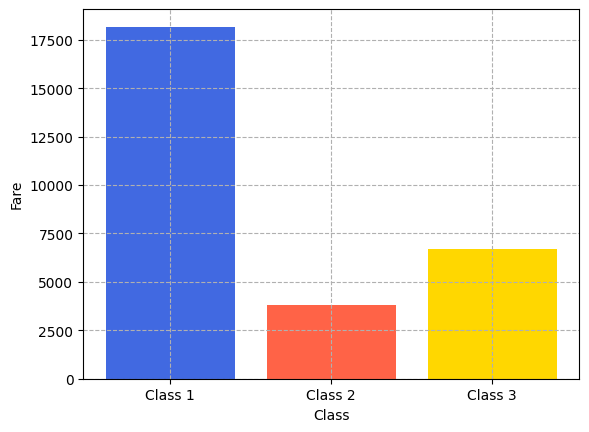

In [69]:
fare_class = df1.groupby('Pclass')['Fare'].sum().sort_index()

plt.bar(fare_class.index, fare_class.values, color=['royalblue', 'tomato', 'gold'])
plt.xticks(fare_class.index, labels=['Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Class')
plt.ylabel('Fare')
plt.grid(True, linestyle='--')
plt.show()


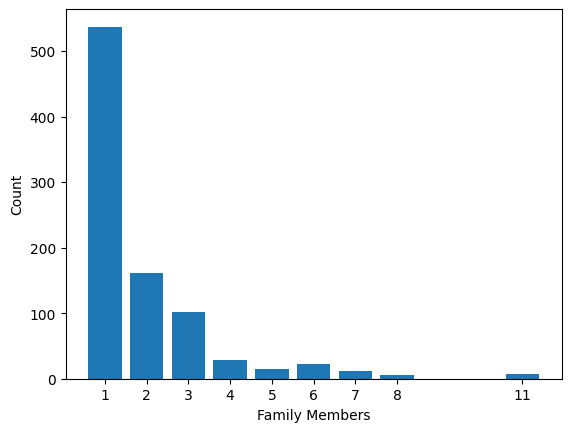

In [70]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
family = df['FamilySize'].value_counts().sort_index()

plt.bar(family.index, family.values)
plt.xlabel('Family Members')
plt.ylabel('Count')
plt.xticks(family.index)
plt.show()

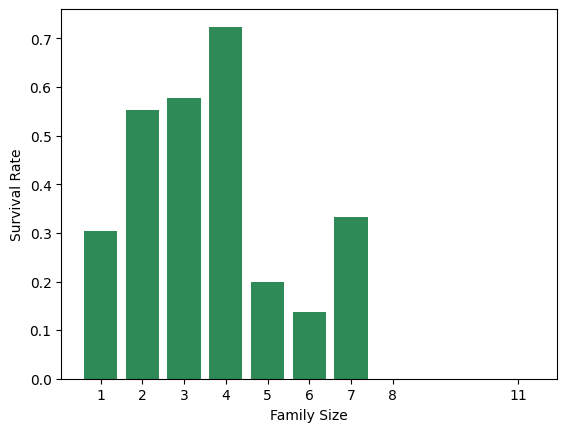

In [71]:
family_survival = df.groupby('FamilySize')['Survived'].mean()

plt.bar(family_survival.index, family_survival.values, color='seagreen')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.xticks(family.index)
plt.show()

In [72]:
mean = df1.mean(numeric_only=True)
median = df1.median(numeric_only=True)
mode = df1.mode().iloc[0]

stats = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Mode': mode
})

print(stats)

                   Mean    Median                 Mode
Age           29.699118   28.0000                 24.0
Cabin               NaN       NaN              B96 B98
Embarked            NaN       NaN                    S
Fare          32.204208   14.4542                 8.05
Name                NaN       NaN  Abbing, Mr. Anthony
Parch          0.381594    0.0000                  0.0
PassengerId  446.000000  446.0000                    1
Pclass         2.308642    3.0000                  3.0
Sex                 NaN       NaN                 male
SibSp          0.523008    0.0000                  0.0
Survived       0.383838    0.0000                  0.0
Ticket              NaN       NaN                 1601


In [73]:
df1['FamilySize'] = df1['SibSp'] + df1['Parch'] + 1

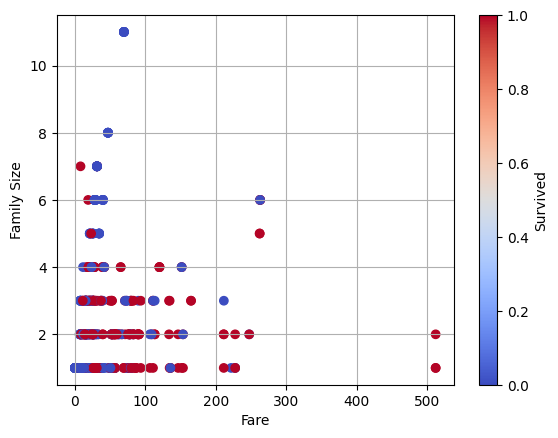

In [74]:
plt.scatter(df1['Fare'], df1['FamilySize'], c = df['Survived'], cmap='coolwarm')
plt.xlabel('Fare')
plt.colorbar(label='Survived')
plt.ylabel('Family Size')
plt.grid(True)
plt.show()

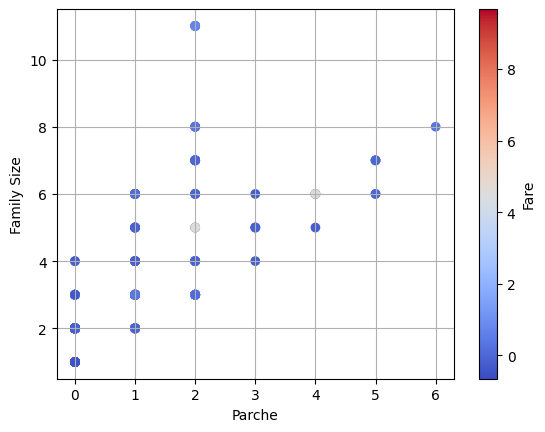

In [75]:
plt.scatter(df['Parch'], df['FamilySize'], c = df['Fare'], cmap='coolwarm')
plt.xlabel('Parche')
plt.colorbar(label='Fare')
plt.ylabel('Family Size')
plt.grid(True)
plt.show()

In [76]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'hasCabin', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'FamilySize'],
      dtype='object')

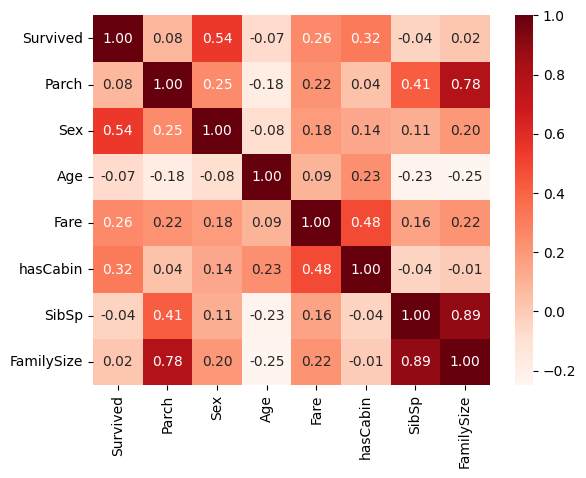

In [77]:
cols = ['Survived', 'Parch', 'Sex', 'Age', 'Fare', 'hasCabin', 'SibSp', 'FamilySize']
df_subset = df[cols]
corr = df_subset.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds')
plt.show()

In [78]:
pip install ydata_profiling

In [79]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)

profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:00<00:00, 37.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]